# Sequence Models — RNN, LSTM, and GRU 


## 0. Setup

In [1]:
import math
import random

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print("torch:", torch.__version__)
print("device:", DEVICE)


torch: 2.14.0
device: mps


## 1. Why do we need sequence models at all?

So far in this course, every model has consumed a *fixed-size*, *order-independent-ish* input — a vector of tabular features, or a 224×224 image. Text, audio, sensor readings, stock prices, and DNA are different: they arrive as a **sequence** of tokens, and *the order carries meaning*.

- **Fixed input size.** An MLP's first layer has a fixed number of input weights. A 5-word sentence and a 50-word sentence can't both be fed to the same MLP without padding/truncating to one arbitrary length — and even then, the MLP has no built-in notion that position 3 and position 30 might both be "the subject of the sentence."
- **No parameter sharing across positions.** An MLP learns an entirely separate set of weights for "word in position 1" vs. "word in position 2." If the model has never seen the word "excellent" in position 7 during training, it has learned nothing about what to do with "excellent" in position 7, even if it has seen "excellent" a thousand times in position 2.
- **No notion of order.** If you feed an MLP (or, similarly, a plain bag-of-words representation) the *set* of words in a sentence with no positional structure, "dog bites man" and "man bites dog" can end up represented identically — despite meaning opposite things.

In [2]:
vocab = ["dog", "bites", "man"]

def bag_of_words(sentence, vocab):
    counts = [sentence.count(w) for w in vocab]
    return counts

sentence_a = ["dog", "bites", "man"]
sentence_b = ["man", "bites", "dog"]

print("sentence A:", " ".join(sentence_a), " -> BoW:", bag_of_words(sentence_a, vocab))
print("sentence B:", " ".join(sentence_b), " -> BoW:", bag_of_words(sentence_b, vocab))
print("Identical BoW vectors, opposite meaning:", bag_of_words(sentence_a, vocab) == bag_of_words(sentence_b, vocab))


sentence A: dog bites man  -> BoW: [1, 1, 1]
sentence B: man bites dog  -> BoW: [1, 1, 1]
Identical BoW vectors, opposite meaning: True


## 2. What counts as "sequential data", and what shapes of problem exist?

**Real-world sequential data:** text (sequence of words/characters), speech/audio (sequence of waveform samples), video (sequence of frames), time series (stock prices, sensor readings, weather), DNA/protein sequences, user click-streams.

**WHAT changes across sequence problems is how many items go IN vs. come OUT:**

```text
one-to-one    :  fixed input  -> fixed output        (not really "sequential" -- a normal classifier)
one-to-many   :  single input -> SEQUENCE output      e.g. image -> caption ("a dog running on grass")
many-to-one   :  SEQUENCE in  -> single output         e.g. sentence -> sentiment (positive/negative)
many-to-many  :  SEQUENCE in  -> SEQUENCE out, aligned  e.g. video frames -> per-frame action label
seq2seq       :  SEQUENCE in  -> SEQUENCE out, unaligned e.g. English sentence -> French sentence
```

**This notebook's running example (Section 15) is many-to-one**: a variable-length sentence goes in, a single positive/negative sentiment label comes out. The mechanics you learn (the recurrent cell, the gates) are IDENTICAL across all five shapes above — only how you read out a prediction from the sequence of hidden states changes.

## 3. RNN, LSTM, GRU — the idea, in short

All three are "recurrent" layers — they read a sequence one item at a time and carry a **hidden state** forward as a running summary of everything read so far. The difference is entirely in *how carefully* that hidden state is updated at each step.

```text
Vanilla RNN:  hidden state is fully overwritten every step
              -> simplest, but forgets long-range information (vanishing gradient)

LSTM:         hidden state PLUS a separate "cell state" (a protected memory),
              managed by 3 gates (forget / input / output)
              -> can preserve information across many steps, at ~4x the parameters

GRU:          same protected-memory idea as LSTM, merged into one state,
              managed by 2 gates (update / reset)
              -> nearly as strong as LSTM, ~25% fewer parameters
```

all three share the exact same PyTorch call signature — `nn.RNN(...)`, `nn.LSTM(...)`, `nn.GRU(...)` all take `(input_size, hidden_size, batch_first=True)` and return `(output, hidden)` (LSTM's `hidden` is a `(h, c)` pair; RNN/GRU's is just `h`). That means we can build **one** model class and swap the recurrent layer by name — exactly what Section 6 does.

For the full conceptual walkthrough — every gate's job, the vanishing-gradient measurement, the hand-derived equations — see the companion theory doc. This notebook goes straight from "here's the idea" to "here's all three working on real data."

In [3]:
dummy_input = torch.randn(4, 10, 8)   # (batch=4, seq_len=10, input_size=8)

for name, layer in [("nn.RNN", nn.RNN(8, 16, batch_first=True)),
                     ("nn.LSTM", nn.LSTM(8, 16, batch_first=True)),
                     ("nn.GRU", nn.GRU(8, 16, batch_first=True))]:
    output, hidden = layer(dummy_input)
    hidden_shape = tuple(hidden[0].shape) if isinstance(hidden, tuple) else tuple(hidden.shape)
    print(f"{name:8s}: output {tuple(output.shape)}   hidden {hidden_shape}"
          f"{'  (h_n, c_n) for LSTM' if isinstance(hidden, tuple) else ''}")


nn.RNN  : output (4, 10, 16)   hidden (1, 4, 16)
nn.LSTM : output (4, 10, 16)   hidden (1, 4, 16)  (h_n, c_n) for LSTM
nn.GRU  : output (4, 10, 16)   hidden (1, 4, 16)


## 4. Load a real dataset: Rotten Tomatoes movie reviews

`cornell-movie-review-data/rotten_tomatoes` on the Hugging Face Hub — 10,662 short movie-review snippets, labeled positive or negative. 8,530 train / 1,066 validation / 1,066 test.

it's the same "movie review sentiment" task the theory doc uses for its worked examples, but real — genuinely varied vocabulary, real negation, real sarcasm — instead of hand-written templates. Small enough to train all three models in a few minutes on a CPU.

In [4]:
from datasets import load_dataset

raw = load_dataset("cornell-movie-review-data/rotten_tomatoes")
print(raw)

print("\nsample positive review:", raw["train"][1]["text"])
print("sample negative review:", raw["train"][0]["text"])

train_labels = raw["train"]["label"]
print(f"\ntrain class balance: {sum(train_labels)} positive / {len(train_labels) - sum(train_labels)} negative")


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
})

sample positive review: the gorgeously elaborate continuation of " the lord of the rings " trilogy is so huge that a column of words cannot adequately describe co-writer/director peter jackson's expanded vision of j . r . r . tolkien's middle-earth .
sample negative review: the rock is destined to be the 21st century's new " conan " and that he's going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .

train class balance: 4265 positive / 4265 negative


## 5. Preprocessing: clean, tokenize, build a vocabulary, pad

the same pipeline from the NLP preprocessing module (Module 10) — lowercase + strip punctuation, split into words, build a vocabulary from the **training set only** (`<pad>`, `<unk>`, `min_freq`), encode each review to token IDs, pad/truncate to a fixed length.

fitting it on validation/test too would leak information about those sets into preprocessing — the same data-leakage rule from Module 10, applied here.

In [5]:
import re
from collections import Counter
from torch.utils.data import Dataset, DataLoader

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text):
    return clean_text(text).split()

def build_vocab(tokenized_texts, min_freq=2):
    counter = Counter()
    for tokens in tokenized_texts:
        counter.update(tokens)
    vocab = {"<pad>": 0, "<unk>": 1}
    for token, count in counter.items():
        if count >= min_freq:
            vocab[token] = len(vocab)
    return vocab

MAX_LEN = 30
train_tokens = [tokenize(t) for t in raw["train"]["text"]]
vocab = build_vocab(train_tokens, min_freq=2)
print(f"vocabulary size (min_freq=2, train only): {len(vocab):,}")


vocabulary size (min_freq=2, train only): 8,971


In [6]:
class ReviewDataset(Dataset):
    def __init__(self, hf_split, vocab, max_len=MAX_LEN):
        self.tokens = [tokenize(t) for t in hf_split["text"]]
        self.labels = hf_split["label"]
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.tokens)

    def __getitem__(self, idx):
        tokens = self.tokens[idx][: self.max_len]
        ids = [self.vocab.get(t, self.vocab["<unk>"]) for t in tokens]
        length = len(ids)
        ids = ids + [self.vocab["<pad>"]] * (self.max_len - length)
        return torch.tensor(ids), length, self.labels[idx]

BATCH_SIZE = 64
train_loader = DataLoader(ReviewDataset(raw["train"], vocab), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(ReviewDataset(raw["validation"], vocab), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(ReviewDataset(raw["test"], vocab), batch_size=BATCH_SIZE, shuffle=False)

ids, length, label = next(iter(train_loader))
print("one batch: ids", tuple(ids.shape), " lengths", tuple(length.shape), " labels", tuple(label.shape))


one batch: ids (64, 30)  lengths (64,)  labels (64,)


## 6. One reusable classifier: `Embedding -> [RNN | LSTM | GRU] -> Linear`

a single model class that builds whichever recurrent layer you ask for by name, so the *only* thing that changes between the three experiments below is one string argument.

our batches are padded to `MAX_LEN`, but most real reviews are shorter. Without telling the recurrent layer the *real* length of each sequence, it would keep updating the hidden state on meaningless `<pad>` tokens too. `pack_padded_sequence` tells PyTorch to stop processing each sequence at its real length, so `h_n` (the final hidden state) is genuinely "the state after the last real word," matching exactly what the theory doc describes.

In [7]:
class SequenceClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, cell_type, num_classes=2, pad_idx=0):
        super().__init__()
        self.cell_type = cell_type
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        rnn_class = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[cell_type]
        self.rnn = rnn_class(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, ids, lengths):
        embedded = self.embedding(ids)                                   # (batch, seq_len, embed_dim)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, hidden = self.rnn(packed)
        h_n = hidden[0] if self.cell_type == "lstm" else hidden           # LSTM hidden = (h_n, c_n)
        last_hidden = h_n[-1]                                             # (batch, hidden_dim) -- final layer
        return self.fc(last_hidden)

EMBED_DIM = 64
HIDDEN_DIM = 64
EPOCHS = 6

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    torch.set_grad_enabled(is_train)
    for ids, lengths, labels in loader:
        ids, labels = ids.to(DEVICE), labels.to(DEVICE)
        if is_train:
            optimizer.zero_grad()
        logits = model(ids, lengths)
        loss = criterion(logits, labels)
        if is_train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * ids.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        n += ids.size(0)
    torch.set_grad_enabled(True)
    return total_loss / n, correct / n


## 7. Train and compare: RNN vs. LSTM vs. GRU

train the *same* architecture three times, changing only `cell_type`, with the same seed, data, and hyperparameters — the only fair way to compare them.

What to expect: the plain RNN should train less smoothly and land at a lower validation accuracy than LSTM/GRU — this is the vanishing-gradient weakness from the theory doc showing up as a real, measured accuracy gap, not just an abstract claim. LSTM and GRU should land close to each other, with GRU using noticeably fewer parameters to get there.

In [8]:
import copy

torch.manual_seed(SEED)

histories = {}
final_val_acc = {}
param_counts = {}
best_models = {}

for cell_type in ["rnn", "lstm", "gru"]:
    torch.manual_seed(SEED)  # re-seed so all three start from a fair, comparable initialization
    model = SequenceClassifier(len(vocab), EMBED_DIM, HIDDEN_DIM, cell_type).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_val_acc_so_far, best_state = 0.0, None
    for epoch in range(1, EPOCHS + 1):
        train_loss, _ = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, None)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        if val_acc > best_val_acc_so_far:
            best_val_acc_so_far, best_state = val_acc, copy.deepcopy(model.state_dict())
        print(f"[{cell_type.upper():4s}] epoch {epoch}/{EPOCHS} | train loss {train_loss:.4f} | val loss {val_loss:.4f} | val acc {val_acc:.4f}")

    model.load_state_dict(best_state)  # roll back to the best checkpoint, not a possibly-overfit last epoch
    histories[cell_type] = history
    final_val_acc[cell_type] = best_val_acc_so_far
    param_counts[cell_type] = sum(p.numel() for p in model.parameters())
    best_models[cell_type] = model
    print()


[RNN ] epoch 1/6 | train loss 0.6940 | val loss 0.6852 | val acc 0.5516


[RNN ] epoch 2/6 | train loss 0.6649 | val loss 0.6802 | val acc 0.5713


[RNN ] epoch 3/6 | train loss 0.6176 | val loss 0.6406 | val acc 0.6520


[RNN ] epoch 4/6 | train loss 0.5552 | val loss 0.6421 | val acc 0.6614


[RNN ] epoch 5/6 | train loss 0.4775 | val loss 0.6166 | val acc 0.6764


...

[GRU ] epoch 2/6 | train loss 0.6296 | val loss 0.6262 | val acc 0.6548


[GRU ] epoch 3/6 | train loss 0.5395 | val loss 0.6056 | val acc 0.6792


[GRU ] epoch 4/6 | train loss 0.4450 | val loss 0.5978 | val acc 0.6942


[GRU ] epoch 5/6 | train loss 0.3535 | val loss 0.6564 | val acc 0.6961


[GRU ] epoch 6/6 | train loss 0.2667 | val loss 0.6731 | val acc 0.7092



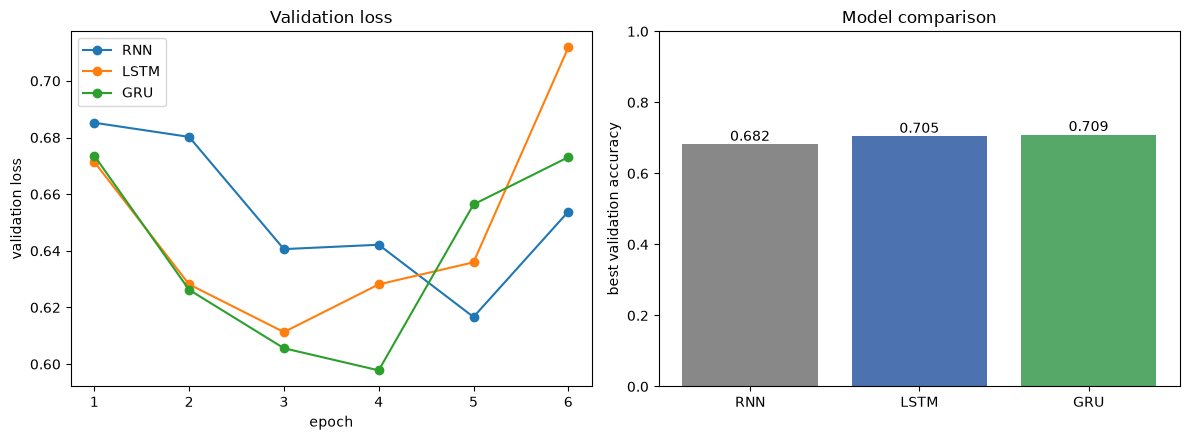

model      params   best val acc
RNN       582,594         0.6820
LSTM      607,554         0.7045
GRU       599,234         0.7092


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for cell_type in ["rnn", "lstm", "gru"]:
    axes[0].plot(range(1, EPOCHS + 1), histories[cell_type]["val_loss"], marker="o", label=cell_type.upper())
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("validation loss"); axes[0].set_title("Validation loss"); axes[0].legend()

names = ["rnn", "lstm", "gru"]
axes[1].bar([n.upper() for n in names], [final_val_acc[n] for n in names], color=["#888", "#4c72b0", "#55a868"])
axes[1].set_ylabel("best validation accuracy"); axes[1].set_ylim(0, 1); axes[1].set_title("Model comparison")
for i, n in enumerate(names):
    axes[1].text(i, final_val_acc[n] + 0.01, f"{final_val_acc[n]:.3f}", ha="center")
plt.tight_layout(); plt.show()

print(f"{'model':6s} {'params':>10s} {'best val acc':>14s}")
for n in names:
    print(f"{n.upper():6s} {param_counts[n]:10,d} {final_val_acc[n]:14.4f}")


## 8. Try it on your own sentences

run the trained LSTM on hand-written sentences it never saw in training — three pairs built by swapping a positive phrase for a negative one (an antonym-substitution test), then two pairs built by literally adding the word "not" (the classic negation test from the theory doc's synthetic example).

a bag-of-words model can hit a respectable accuracy on this dataset just from counting positive/negative words. Antonym-substitution pairs check whether the model picked up on *phrase-level* sentiment cues beyond single words. The literal "not" pairs check something stricter and harder: whether it learned that a single small word can invert the meaning of everything around it — the specific thing the theory doc's synthetic mini-project was built to demonstrate cleanly.

In [10]:
@torch.no_grad()
def predict_sentiment(model, sentence):
    model.eval()
    tokens = tokenize(sentence)[:MAX_LEN]
    ids = [vocab.get(t, vocab["<unk>"]) for t in tokens]
    length = len(ids)
    ids = ids + [vocab["<pad>"]] * (MAX_LEN - length)
    ids_tensor = torch.tensor([ids]).to(DEVICE)
    length_tensor = torch.tensor([length])
    logits = model(ids_tensor, length_tensor)
    probs = torch.softmax(logits, dim=1)[0]
    label = "POSITIVE" if probs[1] > probs[0] else "NEGATIVE"
    return label, probs.max().item()

test_sentences = [
    "smart, funny, and surprisingly touching",
    "dumb, unfunny, and surprisingly boring",
    "an ambitious film that ultimately delivers on its promise",
    "an ambitious film that ultimately fails to deliver on its promise",
    "a beautifully written, deeply moving story",
    "a poorly written, emotionally hollow story",
    "the movie was excellent",
    "the movie was not excellent",
    "this film was a total waste of time",
    "this film was not a total waste of time",
]

for sentence in test_sentences:
    label, confidence = predict_sentiment(best_models["lstm"], sentence)
    print(f"{sentence!r:65s} -> {label:8s} ({confidence:.0%})")


'smart, funny, and surprisingly touching'                         -> POSITIVE (100%)
'dumb, unfunny, and surprisingly boring'                          -> NEGATIVE (99%)
'an ambitious film that ultimately delivers on its promise'       -> POSITIVE (95%)
'an ambitious film that ultimately fails to deliver on its promise' -> NEGATIVE (81%)
'a beautifully written, deeply moving story'                      -> POSITIVE (95%)
'a poorly written, emotionally hollow story'                      -> NEGATIVE (97%)
'the movie was excellent'                                         -> NEGATIVE (64%)
'the movie was not excellent'                                     -> NEGATIVE (75%)
'this film was a total waste of time'                             -> NEGATIVE (99%)
'this film was not a total waste of time'                         -> NEGATIVE (99%)


## Summary — key takeaways

```text
1. Sequence models exist because order carries meaning -- an MLP or bag-of-words can't see it.
2. RNN, LSTM, GRU all carry a hidden state forward; they differ in how carefully it's updated.
   Vanilla RNN overwrites it every step (forgets long-range info). LSTM/GRU protect it with gates.
3. All three share one PyTorch call signature -- nn.RNN / nn.LSTM / nn.GRU -- which is why one
   model class, with the recurrent layer swapped by name, is enough to compare them fairly.
```
